In [1]:
import torch
print(torch.__version__)

2.2.2


In [3]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
import torch.optim as optim 
from torchvision import datasets ,transforms 
from torch.utils.data import DataLoader 
import matplotlib.pyplot as plt

In [4]:
device= torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [6]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset= datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset= datasets.MNIST(root='./data', train=False, download=True, transform=transform) 
train_loader= DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader= DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:08<00:00, 1128502.80it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 102050.51it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:04<00:00, 343559.99it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 5719162.04it/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Number of training samples: 60000
Number of test samples: 10000


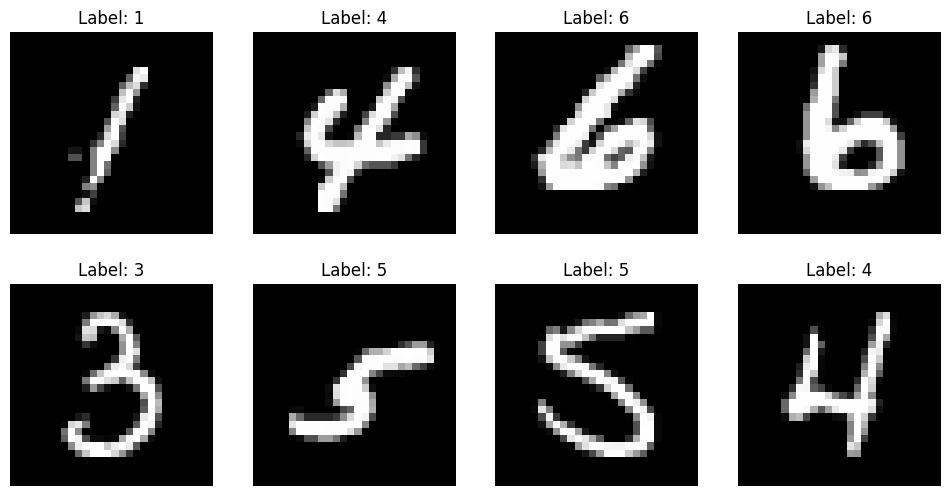

In [7]:
images , labels = next(iter(train_loader)) 
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')
plt.show()


teacher is a boro model 

In [16]:
class TeacherCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        
        
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
    
teacher= TeacherCNN().to(device)
print(teacher)
        
        
        

TeacherCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [11]:
class StudentCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(16 * 14 * 14, 32)
        self.fc2 = nn.Linear(32, 10)
        
    def forward(self, x):
        x= F.relu(self.conv1(x))
        x= self.pool(x)
        x= x.view(-1, 16 * 14 * 14)
        x= F.relu(self.fc1(x))
        x= self.fc2(x)
        return x

In [12]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)    
student_top = StudentCNN().to(device)
print(student_top)
print("Teacher model parameters:", count_parameters(teacher))
print("Student model parameters:", count_parameters(student_top))

StudentCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=10, bias=True)
)
Teacher model parameters: 421642
Student model parameters: 100874


In [13]:
def evaluate(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

In [17]:
def train_teacher(model, train_loader, test_loader, device, epochs=5, learning_rate=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        test_accuracy = evaluate(model, test_loader, device)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Test Accuracy: {test_accuracy:.2f}%")

In [18]:
teacher = TeacherCNN().to(device)
train_teacher(teacher, train_loader, test_loader, device, epochs=5)

Epoch [1/5], Loss: 0.1554, Test Accuracy: 98.60%
Epoch [2/5], Loss: 0.0456, Test Accuracy: 98.73%
Epoch [3/5], Loss: 0.0308, Test Accuracy: 98.60%
Epoch [4/5], Loss: 0.0223, Test Accuracy: 99.17%
Epoch [5/5], Loss: 0.0178, Test Accuracy: 98.98%


In [19]:
def train_student_normal(model,epochs=5): 
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        test_accuracy = evaluate(model, test_loader, device)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Test Accuracy: {test_accuracy:.2f}%")

In [20]:
student_normal= StudentCNN().to(device)
train_student_normal(student_normal, epochs=5)

Epoch [1/5], Loss: 0.3874, Test Accuracy: 95.46%
Epoch [2/5], Loss: 0.1227, Test Accuracy: 97.08%
Epoch [3/5], Loss: 0.0903, Test Accuracy: 97.23%
Epoch [4/5], Loss: 0.0727, Test Accuracy: 97.51%
Epoch [5/5], Loss: 0.0637, Test Accuracy: 97.84%


In [22]:
def train_student_kd(student,teacher,epochs=5,temperature=4.0,alpha=0.5):
    optimizer= optim.Adam(student.parameters(), lr=0.001)
    hard_criterion= nn.CrossEntropyLoss()
    teacher.eval()  
    for epoch in range(epochs):
        student.train()
        running_loss = 0.0
        for images,labels in train_loader: 
            images=images.to(device) 
            labels=labels.to(device)
            optimizer.zero_grad()
            
            with torch.no_grad():
                teacher_logits= teacher(images)
            student_logits= student(images)
            hard_loss= hard_criterion(student_logits,labels)
            teacher_probs= F.softmax(teacher_logits/temperature,dim=1)
            student_log_probs= F.log_softmax(student_logits/temperature,dim=1)
            soft_loss= F.kl_div(student_log_probs,teacher_probs,reduction='batchmean') * (temperature**2)
            loss= alpha*hard_loss + (1-alpha)*soft_loss
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

In [25]:
# Uses train_student_kd's defaults: epochs=5, temperature=4.0, alpha=0.5.
student_id = StudentCNN().to(device)
train_student_kd(student_id, teacher)

Epoch [1/0], Loss: 0.0163
Epoch [1/0], Loss: 0.0315
Epoch [1/0], Loss: 0.0461
Epoch [1/0], Loss: 0.0616
Epoch [1/0], Loss: 0.0770
Epoch [1/0], Loss: 0.0921
Epoch [1/0], Loss: 0.1066
Epoch [1/0], Loss: 0.1213
Epoch [1/0], Loss: 0.1361
Epoch [1/0], Loss: 0.1504
Epoch [1/0], Loss: 0.1653
Epoch [1/0], Loss: 0.1792
Epoch [1/0], Loss: 0.1939
Epoch [1/0], Loss: 0.2078
Epoch [1/0], Loss: 0.2213
Epoch [1/0], Loss: 0.2347
Epoch [1/0], Loss: 0.2480
Epoch [1/0], Loss: 0.2607
Epoch [1/0], Loss: 0.2738
Epoch [1/0], Loss: 0.2867
Epoch [1/0], Loss: 0.2994
Epoch [1/0], Loss: 0.3123
Epoch [1/0], Loss: 0.3249
Epoch [1/0], Loss: 0.3372
Epoch [1/0], Loss: 0.3492
Epoch [1/0], Loss: 0.3612
Epoch [1/0], Loss: 0.3734
Epoch [1/0], Loss: 0.3854
Epoch [1/0], Loss: 0.3970
Epoch [1/0], Loss: 0.4086
Epoch [1/0], Loss: 0.4203
Epoch [1/0], Loss: 0.4314
Epoch [1/0], Loss: 0.4416
Epoch [1/0], Loss: 0.4520
Epoch [1/0], Loss: 0.4623
Epoch [1/0], Loss: 0.4725
Epoch [1/0], Loss: 0.4831
Epoch [1/0], Loss: 0.4928
Epoch [1/0],

KeyboardInterrupt: 